<a href="https://colab.research.google.com/github/RobJavVar/DataSciencePsychNeuro/blob/master/ExerciseSubmissions/13_resampling-methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 13:  Resampling methods

This homework assignment is designed to give you practice with bootstrapping and permutation tests.

You will need to download the **unrestricted_trimmed_1_7_2020_10_50_44.csv** file from the *Homework/hcp_data* folder in the class GitHub repository.

This data is a portion of the [Human Connectome Project database](http://www.humanconnectomeproject.org/). It provides measures of cognitive tasks and brain morphology measuresments from 1206 participants. The full description of each variable is provided in the **HCP_S1200_DataDictionary_April_20_2018.csv** file in the *Homework/hcp_data* folder in the class GitHub repository.

---
## 1. Loading & Visualizing the Data (1 point)

Use the `setwd` and `read.csv` functions to load data from the **unrestricted_trimmed_1_7_2020_10_50_44.csv** file.

(a) Using the tidyverse tools, make a new dataframe `d1` that only inclues the subject ID (`Subject`), gender (`Gender`, self reported at time of data collection), Flanker Task performance (`Flanker_Unadj`), total intracranial volume (`FS_IntraCranial_Vol`), total white matter volume (`FS_Tot_WM_Vol`), and total grey matter volume (`FS_Total_GM_Vol`) variables and remove all _na_ values.

Use the `head` function to look at the first few rows of each data frame.

In [1]:
# WRITE YOUR CODE HERE
library(tidyverse)

setwd("/Users/Ali/Documents/GitHub/DataSciencePsychNeuro/Exercise datasets/hcp_data")

hcp <- read.csv("unrestricted_trimmed_1_7_2020_10_50_44.csv")

d1 <- hcp %>%
  select(Subject, Gender, Flanker_Unadj, FS_IntraCranial_Vol, FS_Tot_WM_Vol, FS_Total_GM_Vol) %>%
  drop_na()

head(d1)


Warning message:
“package ‘ggplot2’ was built under R version 4.5.2”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.1     ✔ stringr   1.5.2
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


,Subject,Gender,Flanker_Unadj,FS_IntraCranial_Vol,FS_Tot_WM_Vol,FS_Total_GM_Vol
,<int>,<chr>,<dbl>,<dbl>,<int>,<int>
1,100206,M,130.42,1864518,543134,807245
2,100307,F,112.56,1512540,407292,664124
3,100408,M,121.18,1684117,500417,726206
4,100610,M,126.53,1816044,512946,762308
5,101006,F,101.85,1437868,429449,579632
6,101107,M,107.04,1512727,416995,665024


(b) Plot grey matter volume (x axis) against intracranial volume (y axis) and Gender (point color).

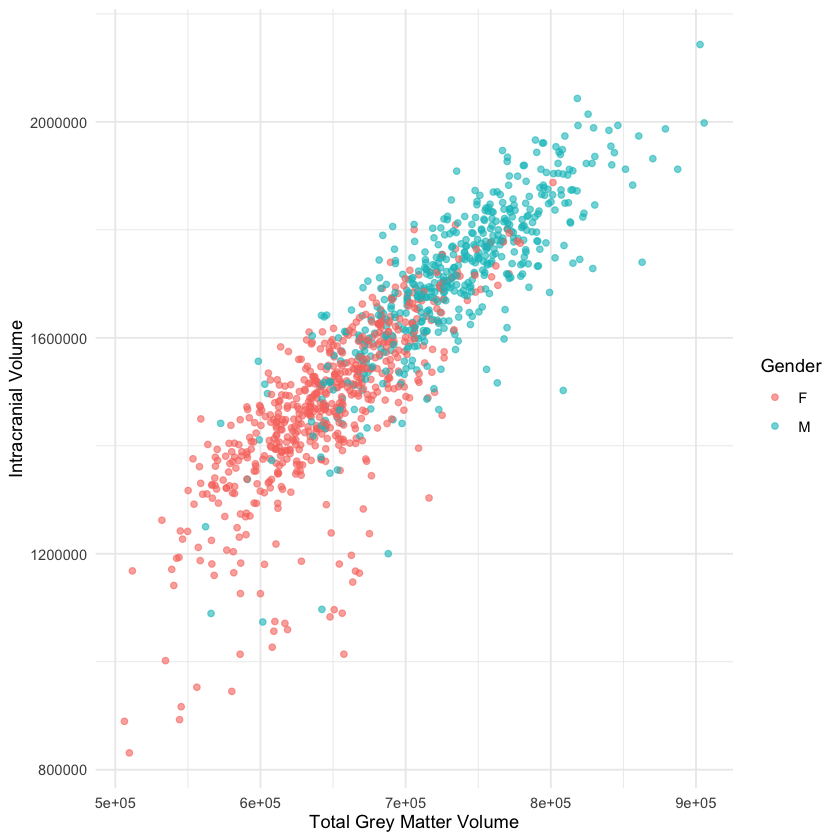

In [2]:
# WRITE YOUR CODE HERE

ggplot(d1, aes(x=FS_Total_GM_Vol, y=FS_IntraCranial_Vol, color=Gender)) +
  geom_point(alpha = 0.6) +      
  labs(
    x = "Total Grey Matter Volume",
    y = "Intracranial Volume",
    color = "Gender") +
  theme_minimal()


What patterns do you observe in the scatter plot?

> *Write your response here*
>In the full sample, as total grey matter volumen increases, ICV increases. This positive relationship exists in both men and women; however, women generally exhibit lower total grey matter volume and smaller ICV compared to men. There also appears to be a decent degree of overlap between genders.


---
## 2. Logistic classifier (2 points)

We want to try predicting gender using the neural data you have loaded.

(a) Run a logisic regression model to predict gender from total white matter volume, total grey matter volume, and intracranial volume.

In [3]:
# WRITE YOUR CODE HERE

d1$Gender <- as.factor(d1$Gender)

model1 <- glm(Gender ~ FS_Tot_WM_Vol + FS_Total_GM_Vol + FS_IntraCranial_Vol, data = d1,family = binomial)
summary(model1)



Call:
glm(formula = Gender ~ FS_Tot_WM_Vol + FS_Total_GM_Vol + FS_IntraCranial_Vol, 
    family = binomial, data = d1)

Coefficients:
                      Estimate Std. Error z value Pr(>|z|)    
(Intercept)         -2.262e+01  1.347e+00 -16.787  < 2e-16 ***
FS_Tot_WM_Vol        2.140e-06  3.059e-06   0.699    0.484    
FS_Total_GM_Vol      1.959e-05  3.145e-06   6.229 4.70e-10 ***
FS_IntraCranial_Vol  5.020e-06  1.177e-06   4.263 2.01e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1534.13  on 1112  degrees of freedom
Residual deviance:  919.85  on 1109  degrees of freedom
AIC: 927.85

Number of Fisher Scoring iterations: 5


Which factors are signficantly associated with gender?

> *Write your response here*
>Total grey matter volume and ICV

(b) Estimate the prediction accuracy of your model (Note: this is the training set accuracy). Set your prediction threshold to 0.5.

In [9]:
# WRITE YOUR CODE HERE
pred_probs <- predict(model1, type = "response")

pred_class <- ifelse(pred_probs > 0.5, "M", "F") 

pred_class <- factor(pred_class, levels = levels(d1$Gender))

accuracy <- mean(pred_class == d1$Gender)
accuracy

[1] 0.8203055

What is the prediction accuracy for gender from the full model?

>*Write your response here*
> 82% prediction accuracy

---
## 3. Bootstrapped accuracy (3 points)

Use bootstrapping to estimate the confidence intervals of the _prediction accuracy_ of your model (i.e., the confidence of the correlation between $\hat{y}$ and $y$). Plot the histogram of the bootstrapped prediction accuracies and estimate the confidence intervals off of the standard deviation from the bootstrap.


Bootstrap mean accuracy 0.82 
95% CI: 0.795 - 0.845 


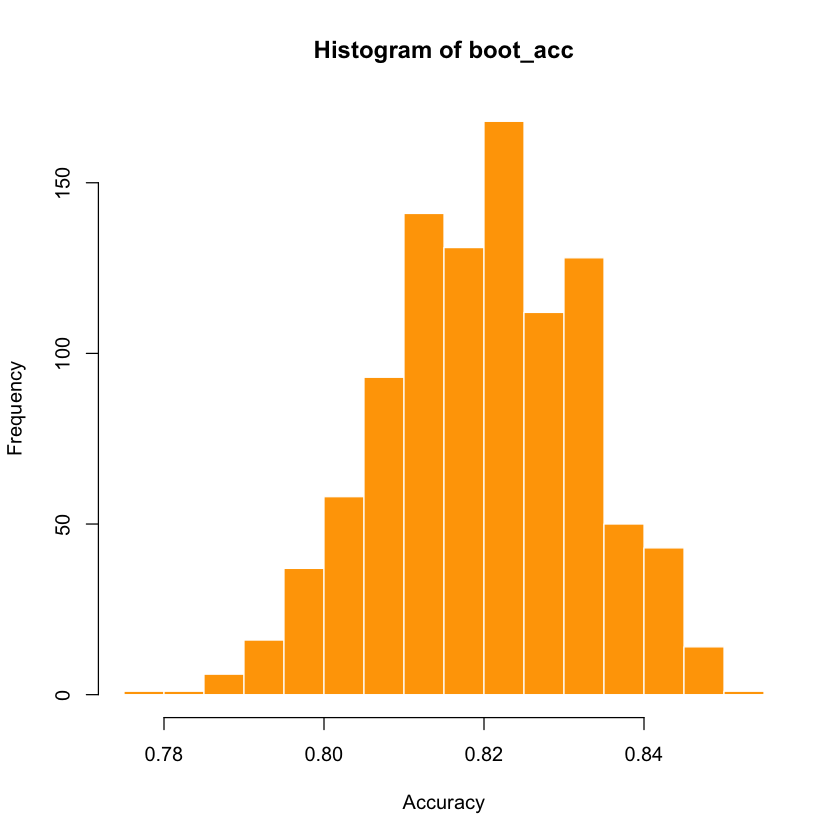

In [14]:
# WRITE YOUR CODE HERE

n_boot <- 1000
boot_acc <- numeric(n_boot)
set.seed(222)

for (i in 1:n_boot) {
  boot_indices <- sample(1:nrow(d1), size = nrow(d1), replace=TRUE)
  boot_data <- d1[boot_indices, ]
 
boot_model <- glm(Gender ~ FS_Tot_WM_Vol + FS_Total_GM_Vol + FS_IntraCranial_Vol, data = boot_data, family = binomial)
  
pred_probs <- predict(boot_model, type="response")
  
pred_class <- ifelse(pred_probs>0.5, "M", "F")
pred_class <- factor(pred_class, levels=levels(d1$Gender))
  
boot_acc[i] <- mean(pred_class == boot_data$Gender)
}

#histogram 
hist(boot_acc, xlab = "Accuracy", col = "orange", border = "white")

mean_acc <- mean(boot_acc)
sd_acc <- sd(boot_acc)
ci_lower <- mean_acc - 2*sd_acc
ci_upper <- mean_acc + 2*sd_acc

cat("Bootstrap mean accuracy", round(mean_acc, 3), "\n")
cat("95% CI:", round(ci_lower, 3), "-", round(ci_upper, 3), "\n")


How robust is the prediction accuracy of the full model?

> *Write your response here*
There is a narrow confidence interval and a high accuracy (0.82) so the model is robust. 

---
## 4. Permutation test for grey matter effects (3 points)

Now run a permutation test, with 1000 iterations, to evaluate how much grey matter volume contributes to the prediction accuracy. Compare the prediction accuracy of the full (unpermuted model) with the distribution of accuracies you get with a randomized grey matter volume term using a histogram (Hint: use the `abline` function to show the original accuracy on the histogram).

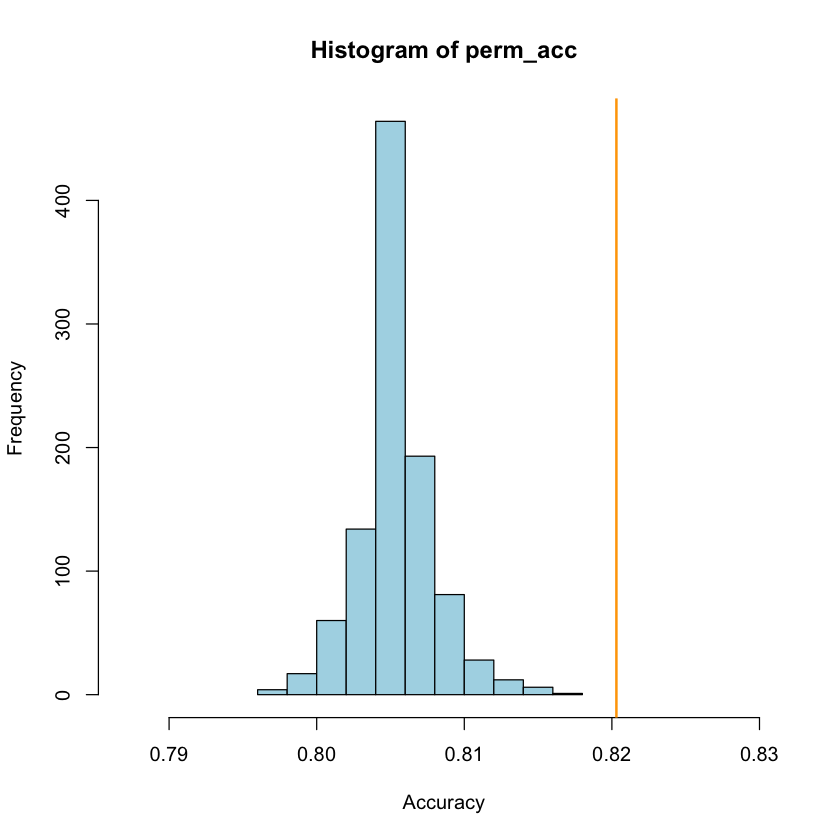

In [18]:
# WRITE YOUR CODE HERE

set.seed(222)
n_perm <- 1000
perm_acc <- numeric(n_perm)

orig_probs <- predict(model1, type="response")
orig_pred <- ifelse(orig_probs>0.5, "M", "F")
orig_pred <- factor(orig_pred, levels=levels(d1$Gender))
orig_acc <- mean(orig_pred == d1$Gender)

for (i in 1:n_perm) {
  d_perm <- d1
  d_perm$FS_Total_GM_Vol <- sample(d_perm$FS_Total_GM_Vol)
  
perm_model <- glm(Gender ~ FS_Tot_WM_Vol + FS_Total_GM_Vol + FS_IntraCranial_Vol, data = d_perm, family = binomial)
  
  perm_probs <- predict(perm_model, type="response")
  perm_pred <- ifelse(perm_probs>0.5, "M", "F")
  perm_pred <- factor(perm_pred, levels= levels(d1$Gender))
  
  perm_acc[i] <- mean(perm_pred == d_perm$Gender)
}

# Histogram
hist(perm_acc, col="lightblue", xlab="Accuracy", xlim= c(min(perm_acc, orig_acc) - 0.01, max(perm_acc, orig_acc) + 0.01))

abline(v=orig_acc, col= "orange", lwd= 2)


How much does the grey matter volume influence the prediction accuracy of the model?

> *Write your response here*
>grey matter volume increases the prediction accuracy of the model by a small amount since the orange line is slightly above the distribution.
> 

---
## 5. Reflection (1 point)

Differentiate the bootstrap from a permutation test. Describe each and when is it appropriate to each.

> *Write your response here*
>Permutation tests work by dissociating the X and Y pairing and reshuffling or rescrambling the data through many iterations. The resulting distribution becomes your null hypothesis, which allows you to compare the observed effect and determine whether there is evidence of an effect.
>
> Bootstrapping uses resampling with replacement to generate a distribution of the statistic and then outputs a confidence interval, showing how large and stable the effect is.
>
> Bootstrapping is not appropriate when cases are unbalanced, whereas permutation tests are useful for testing significance without relying on assumptions. 

**DUE:** 5pm EST, March 24, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> *Someone's Name*